# NLP Course 1 - Week 1 Alternative Assignment

## Movie Review Sentiment Analysis with Logistic Regression

---

## Assignment Overview

**Your Mission**: Build a sentiment analysis classifier for **movie reviews** using Logistic Regression from scratch. Instead of tweets, you'll work with longer, richer text from actual movie reviews.

**Key Difference from Original**: Movie reviews are typically 100-500 words (vs 10-30 words for tweets), contain more complex sentence structures, and use different vocabulary patterns. This will test whether you truly understand the concepts or just memorized tweet-specific implementations.

**Expected Time**: 4-6 hours

**Difficulty**: Intermediate (with gotchas 😈)

---

## Learning Objectives

By completing this assignment, you will demonstrate mastery of:

1. **Text Preprocessing** - Clean and tokenize movie reviews (different patterns than tweets)
2. **Feature Extraction** - Build frequency dictionaries and extract numerical features
3. **Sigmoid Function** - Implement and understand the core activation function
4. **Gradient Descent** - Train your model from scratch using calculus-based optimization
5. **Model Evaluation** - Test on unseen data and calculate accuracy
6. **Error Analysis** - Understand where and why your model fails

---

## Dataset Specification

### Dataset: IMDB Movie Reviews (Simplified Version)

**Source**: You'll need to create or download a simplified version

**Size**: 2000 reviews (1000 positive + 1000 negative)

**Format**: Two text files or a CSV with columns: `review_text`, `sentiment`

### Dataset Structure

```
reviews.csv
├── review: "This movie was absolutely fantastic! The acting was superb..."
└── sentiment: (1 or positive) or (0 or negative)
```

I downloaded the data from https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/data and renamed the file as reviews.csv

### Setup and imports

In [288]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import random
from typing import List, Dict, Tuple, Set
from sklearn.model_selection import train_test_split
import string  

import nltk
# download the stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Part 1: Data Preparation and Preprocessing


### Milestone 1.1: Load and Explore the Data

**What to implement:**

1. Load your movie review dataset
2. Split into training (80%) and test (20%) sets
3. Print basic statistics

**Expected output:**

```
Total reviews: 2000
Positive reviews: 1000
Negative reviews: 1000
Training set size: 1600
Test set size: 400
Average review length: 156 words
```

💡 Hint: Use `random.seed()` for reproducible train/test splits

**🎓 Concepts from Week 1 Material**:

- Supervised Learning setup (Section 1)
- Understanding features (X) and labels (Y)

In [289]:
# read the csv
data  = pd.read_csv("../data/reviews.csv");

print("Data shape ", data.shape)
print("Total data length ", data.shape[0])

# print the first 5 data
data.head(5)

Data shape  (50000, 2)
Total data length  50000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#### Slicing it to 1000 data for quick training demo

In [290]:
# features and labels
X = data[['review']].values
Y = data[["sentiment"]].values

# X = data[['review']].values[:1000]
# Y = data[["sentiment"]].values[:1000]

# print the shape of X and Y
print("X data : ",X[:2])
print("Y data ",Y[:2])

print(X.shape)
print(Y.shape)

X data :  [["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is d

In [291]:
# split the data into 80% train and 20% test data
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Flatten X arrays (they contain strings, need 1D)
X_train = X_train.flatten()
X_test = X_test.flatten()

print("Train X  : ", X_train[:2])
print("Test X  : ", X_test[:2])
print("Train Y  : ", Y_train[:2])
print("Test Y  : ", Y_test[:2])

print("Train X size : ", X_train.shape)
print("Test X size : ", X_test.shape)
print("Train Y size : ", Y_train.shape)
print("Test Y size : ", Y_test.shape)

Train X  :  ['That\'s what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.<br /><br />I must confess, I\'m not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine\'s slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don\'t know what acting school they graduated from, but if I was them I\'d apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we\'ll probably never hear from again. At least, that\'s

In [292]:
# stats
total_reviews = len(data)
positive_reviews = (data['sentiment'] == 'positive').sum()
negative_reviews = (data['sentiment'] == 'negative').sum()
train_size = len(X_train)
test_size = len(X_test)

# average review length in words
data['review_length'] = data['review'].apply(lambda x: len(str(x).split()))
avg_length = data['review_length'].mean()

print(f"Total reviews: {total_reviews}")
print(f"Positive reviews: {positive_reviews}")
print(f"Negative reviews: {negative_reviews}")
print(f"Training set size: {train_size}")
print(f"Test set size: {test_size}")
print(f"Average review length: {avg_length:.0f} words")

Total reviews: 50000
Positive reviews: 25000
Negative reviews: 25000
Training set size: 40000
Test set size: 10000
Average review length: 231 words


### Milestone 1.2: Implement Text Preprocessing Function

**What to implement**: Create a `process_review(review_text)` function

Required steps:

1. Convert to lowercase
2. Remove URLs (movie reviews might have them)
3. Remove HTML tags (e.g., `<br />`)
4. Remove punctuation (but keep emoticons if any)
5. Tokenize into words
6. Remove stopwords
7. Apply stemming

⚠️ GOTCHA #1: Movie reviews use different patterns than tweets!

- Reviews have NO hashtags or @mentions
- Reviews have HTML tags like `<br />` and `&nbsp;`
- Reviews use more formal punctuation (semicolons, em-dashes)
- Reviews contain longer compound words

Example input/output:

```python
review = "The movie was absolutely <br /> fantastic! Best film I've seen in 2024."
# Your function should output:
# ['movi', 'absolut', 'fantast', 'best', 'film', 'seen', '2024']
```

Hints:

- Use `re.sub(r'<.*?>', '', text)` for HTML tags
- Use `nltk.corpus.stopwords` for English stopwords
- Use `nltk.stem.PorterStemmer()` for stemming

Concepts from Week 1 Material:
- Preprocessing (Section 5)
- Tokenization and stemming
- Noise removal

In [293]:
# text preprocessing function
def process_review(review_text: str) -> List[str]:
    """
    Complete preprocessing pipeline for review

    Args:
        review_text: Raw review string

    Returns:
        processed_words: List of cleaned words
    """

    # Convert to lowercase
    review_text = review_text.lower()


    # Remove URLs (movie reviews might have them)
    review_text = re.sub(r'https?://[^\s\n\r]+', '', review_text)

    # Remove HTML tags (e.g., `<br />`)
    review_text = re.sub(r'<.*?>', '', review_text)

    # Remove punctuation (replace with space)
    review_text = re.sub(r'[^\w\s]', ' ', review_text)

    stopwords_english_set = set(stopwords.words('english'))

    # Keep negation words
    negations = {
        'not', 'no', 'nor', 'neither', 'never', 
        'none', 'nobody', 'nothing', 'nowhere',
        'wasn', 't', 'don', 'doesn', 'didn',
        'won', 'wouldn', 'shouldn', 'couldn',
        'hasn', 'haven', 'isn', 'aren', 'ain',
        'weren', 'hadn', 'mightn', 'mustn',
        'needn', 'shan'
    }
    stopwords_english_set = stopwords_english_set - negations
    

    stemmer = PorterStemmer()

    review_clean = []

    #  Tokenize into words
    word_list = review_text.split()

    for word in word_list:
       # Skip empty strings and stopwords
        if word and word not in stopwords_english_set:
            # Apply stemming
            stem_word = stemmer.stem(word)
            review_clean.append(stem_word)

    return review_clean            



Test your function examples:

In [294]:
# Test case 1: HTML removal
result = process_review("Great movie<br />!")
assert '<br' not in result, "HTML tag not removed"
print("Test 1 passed: HTML tags removed correctly")

# Test case 2: Stopword removal
result = process_review("The movie is very good")
assert 'the' not in result and 'is' not in result and 'very' not in result, "Stopwords not removed"
print("Test 2 passed: Stopwords removed correctly")

# Test case 3: Stemming
result = process_review("He was running fast")
assert 'run' in result, "Word not stemmed correctly"
print("Test 3 passed: Stemming works correctly")


Test 1 passed: HTML tags removed correctly
Test 2 passed: Stopwords removed correctly
Test 3 passed: Stemming works correctly


In [295]:
# Test cases
test_cases = [
    "This movie is great! I love it.",
    "Terrible film, don't watch it!",
    "Best movie ever!!! 10/10",
]

for test in test_cases:
    result = process_review(test)
    print(f"Input:  {test}")
    print(f"Output: {result}\n")

Input:  This movie is great! I love it.
Output: ['movi', 'great', 'love']

Input:  Terrible film, don't watch it!
Output: ['terribl', 'film', 'don', 't', 'watch']

Input:  Best movie ever!!! 10/10
Output: ['best', 'movi', 'ever', '10', '10']



### Milestone 1.3: Build Frequency Dictionary

What to implement: Create `build_freqs(reviews, labels)` function

Function signature:

```python
def build_freqs(reviews, labels):
    """
    Build frequency dictionary from reviews and their labels

    Args:
        reviews: list of review texts (strings)
        labels: list of labels (1 for positive, 0 for negative)

    Returns:
        freqs: dictionary where
               key = (word, label)
               value = frequency count
    """
    pass  # Your implementation here
```

⚠️ GOTCHA #2: Don't just count ALL word occurrences!

- The key should be a tuple: `(word, label)`
- Count separately for positive and negative reviews
- Example: `("great", 1): 234` means "great" appeared 234 times in positive reviews

Expected structure example:

```python
freqs = {
    ('great', 1): 523,
    ('great', 0): 89,
    ('terrible', 1): 12,
    ('terrible', 0): 456,
}

or 

freqs = {
    ('great', 'positive'): 523,
    ('great', 'negative'): 89,
    ('terrible', 'positive'): 12,
    ('terrible', 'negative'): 456,
}
```

Hints:

- Use `zip(reviews, labels)` to iterate through both simultaneously
- Call your `process_review()` function for each review
- Use nested loops: outer for reviews, inner for words

In [296]:
def build_freqs(reviews, labels):
    """
    Build frequency dictionary from reviews and their labels

    Args:
        reviews: list of review texts (strings)
        labels: list of labels (1 for positive, 0 for negative)

    Returns:
        freqs: dictionary where
               key = (word, label)
               value = frequency count
    """
    freqs = {}

    for review,label in zip(reviews,labels):
        # Convert numpy int to Python int
        label = int(label)
        
        # print("review and label in outer for loop : ",review, label)
        # process each review
        processed_review = process_review(review)
        # print("processed_review: ", processed_review)

        for word in processed_review:
            # print("word in processed review : ",word)
            key = (word, label)
            # print(f"key={key} value in freqs = {fresq.get(key,0)}")
            freqs[key] = freqs.get(key,0) + 1
            # print(f"key value after : {freqs.get(key)}")

    return freqs



Test your function:

In [297]:
# Build small freqs dict
test_reviews = ["great movie", "terrible film"]
test_labels = [1, 0]
freqs = build_freqs(test_reviews, test_labels)

# Check structure
assert ('great', 1) in freqs, "Missing ('great', 1) key"
assert ('terribl', 0) in freqs, "Missing ('terribl', 0) key"  # stemmed
assert freqs[('great', 1)] == 1, "Incorrect count for ('great', 1)"

# Additional tests
assert ('movi', 1) in freqs, "Missing ('movi', 1)"
assert ('film', 0) in freqs, "Missing ('film', 0)"
assert ('movi', 0) not in freqs, "Word 'movi' shouldn't appear in negative review"
assert ('terribl', 1) not in freqs, "Word 'terribl' shouldn't appear in positive review"

print("All build_freqs tests passed.")

All build_freqs tests passed.


## Part 2: Feature Extraction


### Milestone 2.1: Extract Features from a Single Review

**What to implement**: Create `extract_features(review, freqs)` function

```python
def extract_features(review, freqs):
    """
    Extract numerical features from a review

    Args:
        review: single review text (string)
        freqs: frequency dictionary from build_freqs()

    Returns:
        x: numpy array of shape (3,) containing:
           [1, sum_positive_freqs, sum_negative_freqs]
    """
    pass  # Your implementation here
```

Feature vector structure:

- `x[0] = 1` (bias term, always 1)
- `x[1] = sum of all word frequencies in positive class`
- `x[2] = sum of all word frequencies in negative class`

⚠️ GOTCHA #3: Handle out-of-vocabulary (OOV) words with `freqs.get((word, label), 0)`

Hints:

- Initialize: `x = np.zeros(3); x[0] = 1`
- Process the review first and loop through words
- Sum positive and negative freqs safely

In [298]:
def extract_features(review, freqs):
    """
    Extract numerical features from a review

    Args:
        review: single review text (string)
        freqs: frequency dictionary from build_freqs()

    Returns:
        x: numpy array of shape (3,) containing:
           [1, sum_positive_freqs, sum_negative_freqs]
    """

    x = np.zeros(3)
    x[0] = 1
    # print("initialized x : ",x)

    # preprocess the review to get list of words
    processed_words = process_review(review)
    # print("processed words : ",processed_words)

    for word in processed_words:
        # positive and negative key of freq for the words in teh review as 
        # positive key = (word, positive class label) or negative key = (word, negative class label)
        pos_key = (word, 1)
        neg_key = (word, 0)

        # pos_key = (word, 'positive')
        # neg_key = (word, 'negative')

        # print(f"pos_key={pos_key} and neg_key={neg_key}")

        # get the values from dict freqs
        pos_count = freqs.get(pos_key, 0)
        neg_count = freqs.get(neg_key, 0)

        # print(f"pos_count={pos_count} and neg_count={neg_count}")

        x[1] += pos_count
        x[2] += neg_count

        # print(f"after post count : x[1]={x[1]} and x[2]={x[2]}")

    return x
    

test cases for check

In [299]:
# Build small frequency dictionary for testing
freqs = {
    ('great', 1): 2,
    ('great', 0): 1,
    ('terribl', 1): 0,
    ('terribl', 0): 3
}

# --- Test case 1: Positive review ---
x = extract_features("great movie", freqs)
assert isinstance(x, np.ndarray), "Output should be a numpy array"
assert x.shape == (3,), "Feature vector should have shape (3,)"
assert x[0] == 1, "Bias term should be 1"
assert x[1] == 2, "Sum of positive freqs incorrect"
assert x[2] == 1, "Sum of negative freqs incorrect"
print("Test 1 passed: Positive review features extracted correctly")

# --- Test case 2: Negative review ---
x = extract_features("terrible film", freqs)
assert x[0] == 1, "Bias term should be 1"
assert x[1] == 0, "Positive freqs incorrect for negative review"
assert x[2] == 3, "Negative freqs incorrect for negative review"
print("Test 2 passed: Negative review features extracted correctly")

# --- Test case 3: Mixed review ---
x = extract_features("great but terrible", freqs)
print(x)
assert x[0] == 1, "Bias term should be 1"
assert x[1] == 2, "Positive freqs incorrect for mixed review"
assert x[2] == 4, "Negative freqs incorrect for mixed review"
print("Test 3 passed: Mixed review features extracted correctly")

# --- Test case 4: OOV words (not in freqs) ---
x = extract_features("unknown words here", freqs)
assert x[0] == 1, "Bias term should be 1"
assert x[1] == 0 and x[2] == 0, "OOV words should contribute zero frequency"
print("Test 4 passed: OOV words handled correctly")

Test 1 passed: Positive review features extracted correctly
Test 2 passed: Negative review features extracted correctly
[1. 2. 4.]
Test 3 passed: Mixed review features extracted correctly
Test 4 passed: OOV words handled correctly


### This function is for the test case where we are not creating the freqs again instead using the freqs from training

In [300]:
def extract_feature_matrix(reviews, freqs):
    """
    Extract feature matrix using pre-computed frequency dictionary.
    
    Args:
        reviews: list or array of review texts (strings)
        freqs: pre-computed frequency dictionary from training
    
    Returns:
        X: feature matrix of shape (m, 3) where m = number of reviews
    """
    m = len(reviews)
    X = np.zeros((m, 3))
    
    for i, review in enumerate(reviews):
        X[i, :] = extract_features(review, freqs)
    
    return X

### Milestone 2.2: Build Feature Matrix for All Reviews

**What to implement**: Create `build_feature_matrix(reviews, labels)` function

```python
def build_feature_matrix(reviews, labels):
    """
    Build feature matrix for all reviews

    Args:
        reviews: list of review texts
        labels: list of labels

    Returns:
        X: numpy array of shape (m, 3) where m = number of reviews
        freqs: the frequency dictionary (needed later for test set)
    """
    pass  # Your implementation here
```

⚠️ GOTCHA #4: Efficiency matters — build freqs once, then extract features for each review.

Hints:

- Call `build_freqs()` once, then `extract_features()` per review
- Preallocate array or use `np.vstack()`

In [301]:
def build_feature_matrix(reviews, labels):
    """
    Build feature matrix for all reviews

    Args:
        reviews: list of review texts
        labels: list of labels

    Returns:
        X: numpy array of shape (m, 3) where m = number of reviews
        freqs: the frequency dictionary (needed later for test set)
    """

    # build frequency using the function build_freqs
    freqs = build_freqs(reviews, labels)

    # print(f"freqs created - f{freqs}")

    features = []
    
    for review in reviews:

        extracted_features = extract_features(review, freqs)

        features.append(extracted_features)

    # stack all feature into one numpy array
    X = np.vstack(features)

    return X, freqs



test cases for check

In [302]:
# test 1 - basic feature matrix creation
print("# test 1 - simple feature matrix build")

reviews = [
    "I love this movie",      # positive
    "This movie was terrible" # negative
]
labels = [1,0]

# Build the feature matrix
X, freqs = build_feature_matrix(reviews, labels)

# print("X ",X)
# print("freqs ",freqs)

# Expected keys in freqs
expected_keys = [
    ('love', 1),
    ('movi', 1),
    ('terribl', 0),
    ('movi', 0)
]

for key in expected_keys:
    assert key in freqs, f"{key} missing from freqs"

# Check feature matrix shape
assert X.shape == (2, 3), f"Expected shape (2,3), got {X.shape}"

# Check bias term
assert np.all(X[:, 0] == 1), "Bias term (x[0]) should be 1 for all reviews"

print("Test 1 passed: Basic feature matrix built correctly\n")


# test 2 - feature sums reflect frequencies
print("# test 2 - feature values check")

assert np.any(X[:, 1] > 0), "Some reviews should have positive frequency sum > 0"
assert np.any(X[:, 2] >= 0), "All reviews should have non-negative frequency sums"

print("Test 2 passed: Feature sums reflect frequencies\n")


# test 3 - handles unseen words
print("# test 3 - handles unseen words")

new_reviews = ["This unseen word"]
X_new = np.vstack([extract_features(r, freqs) for r in new_reviews])

assert np.all(X_new[:, 1:] >= 0), "OOV words should contribute 0 frequency"

print("Test 3 passed: OOV words handled correctly\n")

print("All build_feature_matrix tests passed.")


# test 1 - simple feature matrix build
Test 1 passed: Basic feature matrix built correctly

# test 2 - feature values check
Test 2 passed: Feature sums reflect frequencies

# test 3 - handles unseen words
Test 3 passed: OOV words handled correctly

All build_feature_matrix tests passed.


### Normalize Features

In [303]:
def normalize_features(X):
    """
    Normalize features using mean and standard deviation.
    DO NOT normalize the bias column (column 0)!
    
    Args:
        X: feature matrix (m, 3)
           Column 0: bias (all 1s)
           Column 1: sum of positive frequencies
           Column 2: sum of negative frequencies
    
    Returns:
        X_norm: normalized features (m, 3)
        mu: mean of each feature (excluding bias)
        sigma: std of each feature (excluding bias)
    """
    X_norm = X.copy()
    
    # Calculate mean and std for columns 1 and 2 (skip bias column 0)
    mu = np.mean(X[:, 1:], axis=0)
    sigma = np.std(X[:, 1:], axis=0)
    
    # Normalize columns 1 and 2
    X_norm[:, 1:] = (X[:, 1:] - mu) / sigma
    
    return X_norm, mu, sigma

def normalize_test_features(X_test, mu, sigma):
    """
    Normalize test features using training statistics.
    
    Args:
        X_test: test feature matrix (m, 3)
        mu: mean from training data
        sigma: std from training data
    
    Returns:
        X_test_norm: normalized test features
    """
    X_test_norm = X_test.copy()
    X_test_norm[:, 1:] = (X_test[:, 1:] - mu) / sigma
    return X_test_norm

## Part 3: Logistic Regression Implementation


### Milestone 3.1: Implement the Sigmoid Function

**What to implement**: Create `sigmoid(z)` function

```python
def sigmoid(z):
    """
    Compute sigmoid function

    Args:
        z: scalar or numpy array

    Returns:
        h: sigmoid(z), same shape as z
    """
    pass  # Your implementation here
```

⚠️ GOTCHA #5: Numerical overflow — use `np.clip(z, -500, 500)` before computing `np.exp()`.

Tests:

- `sigmoid(0) == 0.5`
- Works for arrays and extreme values without producing NaN/Inf

In [304]:
def sigmoid(z):
    """
    Compute sigmoid function

    Args:
        z: scalar or numpy array

    Returns:
        h: sigmoid(z), same shape as z
    """

    z_clipped = np.clip(z, -500, 500)

    h = 1 / (1 + np.exp(-z_clipped))

    return h
    

test cases for check

In [305]:
# test 1 - basic scalar input
print("# test 1 - scalar input")

assert np.isclose(sigmoid(0), 0.5), "Sigmoid(0) should be 0.5"
assert np.isclose(sigmoid(2), 1 / (1 + np.exp(-2))), "Incorrect value for sigmoid(2)"
assert np.isclose(sigmoid(-2), 1 / (1 + np.exp(2))), "Incorrect value for sigmoid(-2)"

print("Test 1 passed: Scalar input works correctly\n")


# test 2 - array input
print("# test 2 - array input")

z = np.array([0, 1, -1])
expected = 1 / (1 + np.exp(-z))
h = sigmoid(z)

assert np.allclose(h, expected), "Sigmoid failed for numpy array input"
assert h.shape == z.shape, "Output shape should match input shape"

print("Test 2 passed: Array input handled correctly\n")


# test 3 - numerical stability with large values
print("# test 3 - numerical stability")

large_vals = np.array([-1000, 0, 1000])
h = sigmoid(large_vals)

# Should not contain NaN or Inf
assert not np.any(np.isnan(h)), "Sigmoid produced NaN for large inputs"
assert not np.any(np.isinf(h)), "Sigmoid produced Inf for large inputs"

# Should saturate properly
assert np.isclose(h[0], 0.0, atol=1e-6), "Sigmoid(-1000) should approach 0"
assert np.isclose(h[2], 1.0, atol=1e-6), "Sigmoid(1000) should approach 1"

print("Test 3 passed: Handles large values safely\n")

print("All sigmoid() tests passed")


# test 1 - scalar input
Test 1 passed: Scalar input works correctly

# test 2 - array input
Test 2 passed: Array input handled correctly

# test 3 - numerical stability
Test 3 passed: Handles large values safely

All sigmoid() tests passed


### Milestone 3.2: Implement Gradient Descent

**What to implement**: Create `gradient_descent(X, y, theta, alpha, num_iters)` function

```python
def gradient_descent(X, y, theta, alpha, num_iters):
    """
    Train logistic regression using gradient descent

    Args:
        X: feature matrix (m, 3)
        y: labels (m, 1)
        theta: initial parameters (3, 1)
        alpha: learning rate (e.g., 1e-9)
        num_iters: number of iterations (e.g., 1500)

    Returns:
        J: final cost
        theta: trained parameters
    """
    pass  # Your implementation here
```

Algorithm outline and GOTCHAs:

- Compute predictions: `h = sigmoid(X @ theta)`
- Gradient: `grad = (1/m) * X.T @ (h - y)`
- Update: `theta = theta - alpha * grad`
- Cost: `J = (-1/m) * (y.T @ log(h) + (1-y).T @ log(1-h))` (add epsilon)
- Watch shapes: X (m,3), theta (3,1), y (m,1)
- Start with `alpha = 1e-9` for movie reviews

In [306]:

def gradient_descent(X, y, theta, alpha, num_iters):
    """
    Train logistic regression using gradient descent

    Args:
        X: feature matrix (m, 3)
        y: labels (m, 1)
        theta: initial parameters (3, 1)
        alpha: learning rate (e.g., 1e-9)
        num_iters: number of iterations (e.g., 1500)

    Returns:
        J: final cost
        theta: trained parameters
        cost_history: list of cost per iteration
    """

    m = len(y)
    cost_history = []  # store cost at each iteration
    
    for iteration in range(num_iters):

        # forward pass - make prediction
        z = np.dot(X, theta)
        h = sigmoid(z)

        # print("z in here ", z)
        # print("h in here ",h)

        # calculate the cost function
        h_clipped = np.clip(h, 1e-15, 1 - 1e-15)
        J = (-1/m) * np.sum(y * np.log(h_clipped) + (1-y) * np.log(1-h_clipped))

        # store cost
        cost_history.append(J)

        # compute gradient
        gradient = (1/m) * np.dot(X.T, (h-y))

        # update params
        theta = theta - (alpha*gradient)

        # print cost after every 100 iterations
        if iteration % 100 == 0:
            print(f"Cost after {iteration} iterations = {J:.6f}")

    print(f"Final cost: {J:.6f}")
    print("Final theta:\n", theta)

    J = float(J)
        
    return J , theta, cost_history
    

Test cases for check

In [307]:
# test 1 - verify output types and shapes
print("# test 1 - output types and shapes")

X = np.array([
    [1, 0.5, 1.5],
    [1, 1.0, 2.0],
    [1, 1.5, 0.5],
    [1, 3.0, 4.0]
])
y = np.array([[0], [0], [1], [1]])
theta = np.zeros((3, 1))
alpha = 0.1
num_iters = 10

J, theta_out, cost_history = gradient_descent(X, y, theta, alpha, num_iters)

assert np.isscalar(J) or isinstance(J, (float, np.floating)), "Cost J should be a scalar or float"
assert theta_out.shape == theta.shape, "Theta output shape should match input shape"

print("Test 1 passed: Output types and shapes verified\n")


# test 2 - cost should decrease with iterations
print("# test 2 - cost decreases over iterations")

theta = np.zeros((3, 1))
costs = []
theta_temp = theta.copy()

for _ in range(5):
    J, theta_temp , _ = gradient_descent(X, y, theta_temp, alpha, 1)
    costs.append(J)

assert costs[-1] <= costs[0], f"Cost did not decrease: {costs}"
print("Test 2 passed: Cost decreases over iterations\n")


# test 3 - learned theta should produce valid predictions
print("# test 3 - prediction sanity check")

J, theta_trained, _ = gradient_descent(X, y, np.zeros((3, 1)), alpha, 200)
probs = sigmoid(X @ theta_trained)
preds = (probs >= 0.5).astype(int)

assert preds.shape == y.shape, "Predictions shape mismatch"
assert np.all((preds == 0) | (preds == 1)), "Predictions must be binary"
print("Test 3 passed: Predictions are binary and valid\n")


# test 4 - numerical stability for large values
print("# test 4 - numerical stability check")

X_large = np.array([[1, 1000, -1000]])
y_large = np.array([[1]])
theta_large = np.zeros((3, 1))

try:
    J, theta_stable, _ = gradient_descent(X_large, y_large, theta_large, 0.01, 10)
    assert not np.isnan(J), "Cost became NaN for large input"
    assert not np.any(np.isnan(theta_stable)), "Theta has NaN values"
except Exception as e:
    raise AssertionError(f"Gradient descent failed on large values: {e}")

print("Test 4 passed: Handles large values without numerical issues\n")


# test 5 - convergence with small learning rate
print("# test 5 - small learning rate convergence")

theta = np.zeros((3, 1))
J1, theta1, _ = gradient_descent(X, y, theta, 1e-3, 200)
J2, theta2, _ = gradient_descent(X, y, theta, 1e-1, 200)

assert J2 < J1 or np.isclose(J1, J2, atol=1e-3), "Higher alpha should improve convergence or remain stable"
print("Test 5 passed: Converges under different learning rates\n")

print("All gradient_descent() tests passed.")


# test 1 - output types and shapes
Cost after 0 iterations = 0.693147
Final cost: 0.620208
Final theta:
 [[-0.05167117]
 [ 0.2663989 ]
 [-0.01150731]]
Test 1 passed: Output types and shapes verified

# test 2 - cost decreases over iterations
Cost after 0 iterations = 0.693147
Final cost: 0.693147
Final theta:
 [[0.    ]
 [0.0375]
 [0.0125]]
Cost after 0 iterations = 0.678635
Final cost: 0.678635
Final theta:
 [[-0.00202874]
 [ 0.07086639]
 [ 0.01961865]]
Cost after 0 iterations = 0.667616
Final cost: 0.667616
Final theta:
 [[-0.00560241]
 [ 0.10104478]
 [ 0.02264782]]
Cost after 0 iterations = 0.658688
Final cost: 0.658688
Final theta:
 [[-0.0103502 ]
 [ 0.12876135]
 [ 0.02257867]]
Cost after 0 iterations = 0.651024
Final cost: 0.651024
Final theta:
 [[-0.01599084]
 [ 0.15456583]
 [ 0.02016094]]
Test 2 passed: Cost decreases over iterations

# test 3 - prediction sanity check
Cost after 0 iterations = 0.693147
Cost after 100 iterations = 0.322059
Final cost: 0.201390
Final theta:
 [[-1

#### Why we use `h_clipped`

When we compute the cost function in logistic regression:

$$
J = -\frac{1}{m} [y^T \log(h) + (1 - y)^T \log(1 - h)]
$$

the value of `h` comes from the sigmoid function:

$$
h = \frac{1}{1 + e^{-z}}
$$

The sigmoid function outputs values between 0 and 1.
However, for very large or very small values of `z`, the sigmoid can get extremely close to 0 or 1.

Example:

| z   | sigmoid(z) | log(h)   | log(1 - h) |
| --- | ---------- | -------- | ---------- |
| 10  | 0.99995    | -0.00005 | -inf       |
| -10 | 0.00005    | -inf     | -0.00005   |

When `h` becomes exactly 0 or 1, the term `log(h)` or `log(1 - h)` becomes infinite.
This causes the cost to become `NaN` (not a number).

To prevent this, we clip the values of `h` slightly away from 0 and 1:

```python
h_clipped = np.clip(h, 1e-15, 1 - 1e-15)
```

This ensures that:

* `h` is never less than 1e-15
* `h` is never greater than 1 - 1e-15

## Part 4: Training Your Model


### Milestone 4.1: Train on Full Training Set

Steps:

1. Build feature matrix X_train and labels y_train
2. Initialize `theta = np.zeros((3, 1))`
3. Train using `gradient_descent`
4. Save trained `theta`

Notes and GOTCHAs:

- Print cost every 100 iterations to monitor progress
- `y_train` must be shape (m,1), not (m,)
- If cost increases, reduce learning rate

In [308]:
print("X train : ", X_train)
print("Y train : ", Y_train)


print("\nX train shape : ", X_train.shape)
print("Y train shape", Y_train.shape)

X train :  ['That\'s what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.<br /><br />I must confess, I\'m not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine\'s slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don\'t know what acting school they graduated from, but if I was them I\'d apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we\'ll probably never hear from again. At least, that\'s 

#### check the data to make sure its in our desired shape

In [309]:
print("X train:", X_train[0:3])
print("Y train:", Y_train[0:3])

print("\nX train shape:", X_train.shape)
print("Y train shape:", Y_train.shape)

print("X_train 1st example:", X_train[0:3])
print("X_train 2nd example:", Y_train[0:3])

# Convert Y_train to numeric labels (1 for positive, 0 for negative)
Y_train_numeric = np.array([1 if label == 'positive' else 0 for label in Y_train.flatten()]).reshape(-1, 1)

print("Y_train_numeric shape:", Y_train_numeric.shape)

print("Y_train_numeric first 5:")
print(Y_train_numeric[:5])

X train: ['That\'s what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensional characters, who have so little depth that it is virtually impossible to care what happens to them. They are just badly written cyphers for the director to hang his multicultural beliefs on, a topic that has been done much better in other dramas both on TV and the cinema.<br /><br />I must confess, I\'m not really one for spotting bad performances during a film, but it must be said that Nichola Burley (as the heroine\'s slutty best friend) and Wasim Zakir (as the nasty, bullying brother) were absolutely terrible. I don\'t know what acting school they graduated from, but if I was them I\'d apply for a full refund post haste. Only Samina Awan in the lead role manages to impress in a cast of so-called British talent that we\'ll probably never hear from again. At least, that\'s th

In [310]:
print("Step 1: Convert Labels")
Y_train_numeric = np.array([1 if label == 'positive' else 0 for label in Y_train.flatten()]).reshape(-1, 1)
print(f"Y_train_numeric shape: {Y_train_numeric.shape}")
print(f"Y_train_numeric first 5: {Y_train_numeric[:5].flatten()}")

Step 1: Convert Labels
Y_train_numeric shape: (40000, 1)
Y_train_numeric first 5: [0 0 1 0 0]


In [311]:
print("\nStep 2: Build Features")
features, freqs = build_feature_matrix(X_train, Y_train_numeric.flatten())
print(f"features shape: {features.shape}")
print(f"features (before scaling) first 3:")
print(features[:3])


Step 2: Build Features


features shape: (40000, 3)
features (before scaling) first 3:
[[1.00000e+00 6.84011e+05 7.54456e+05]
 [1.00000e+00 7.40841e+05 8.85158e+05]
 [1.00000e+00 1.55327e+05 1.21315e+05]]


In [312]:

print("\nStep 3: Normalize Features")
features_norm, mu, sigma = normalize_features(features)
print(f"features_norm shape: {features_norm.shape}")
print(f"features (after scaling) first 3:")
print(features_norm[:3])
print(f"\nMean (mu): {mu}")
print(f"Std (sigma): {sigma}")


Step 3: Normalize Features
features_norm shape: (40000, 3)
features (after scaling) first 3:
[[ 1.          0.52863945  0.5585657 ]
 [ 1.          0.69496945  0.90932483]
 [ 1.         -1.01871241 -1.14056659]]

Mean (mu): [503390.659575 546319.85525 ]
Std (sigma): [341670.18584765 372626.07871693]


In [313]:
print("\nStep 4: Train Model")
m = len(Y_train_numeric)
alpha = 0.5 
num_iters = 2000

theta = np.zeros((3, 1))

J, theta, cost_history = gradient_descent(features_norm, Y_train_numeric, theta, alpha, num_iters)

print(f"\nTraining Complete")
print(f"Final theta:\n{theta}")
print(f"theta shape: {theta.shape}")


Step 4: Train Model
Cost after 0 iterations = 0.693147
Cost after 100 iterations = 0.671008
Cost after 200 iterations = 0.654772
Cost after 300 iterations = 0.641858
Cost after 400 iterations = 0.631488
Cost after 500 iterations = 0.623077
Cost after 600 iterations = 0.616186
Cost after 700 iterations = 0.610490
Cost after 800 iterations = 0.605742
Cost after 900 iterations = 0.601755
Cost after 1000 iterations = 0.598383
Cost after 1100 iterations = 0.595515
Cost after 1200 iterations = 0.593062
Cost after 1300 iterations = 0.590954
Cost after 1400 iterations = 0.589133
Cost after 1500 iterations = 0.587556
Cost after 1600 iterations = 0.586183
Cost after 1700 iterations = 0.584985
Cost after 1800 iterations = 0.583936
Cost after 1900 iterations = 0.583016
Final cost: 0.582213
Final theta:
 [[-0.01717896]
 [ 6.52804661]
 [-6.67816684]]

Training Complete
Final theta:
[[-0.01717896]
 [ 6.52804661]
 [-6.67816684]]
theta shape: (3, 1)


In [314]:
# Check the magnitude of theta
print(f"\nTheta magnitudes:")
print(f"theta[0] = {theta[0, 0]:.10f}")
print(f"theta[1] = {theta[1, 0]:.10f}")
print(f"theta[2] = {theta[2, 0]:.10f}")


Theta magnitudes:
theta[0] = -0.0171789596
theta[1] = 6.5280466115
theta[2] = -6.6781668373


### Plot the cost history

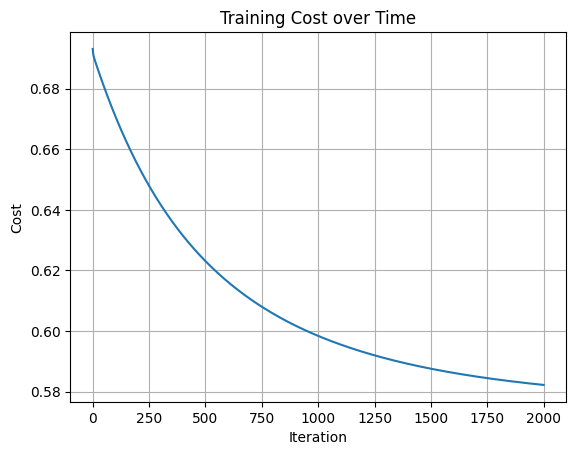

In [315]:
# Simple one-liner plot
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost over Time')
plt.grid(True)
plt.show()

## Part 5: Testing and Evaluation


### Milestone 5.1: Implement Prediction Function

**What to implement**: `predict_sentiment(review, freqs, theta)`

```python
def predict_sentiment(review, freqs, theta):
    """
    Predict sentiment for a single review

    Args:
        review: review text (string)
        freqs: frequency dictionary
        theta: trained parameters (3, 1)

    Returns:
        prediction: 1 (positive) or 0 (negative)
        probability: P(positive)
    """
    pass  # Your implementation here
```

Algorithm:

1. Extract features x
2. z = x · theta
3. h = sigmoid(z)
4. predict = 1 if h >= 0.5 else 0

In [333]:
def predict_sentiment(review, freqs, theta):
    """
    Predict sentiment for a single review

    Args:
        review: review text (string)
        freqs: frequency dictionary
        theta: trained parameters (3, 1)

    Returns:
        prediction: 1 (positive) or 0 (negative)
        probability: P(positive)
    """
    
    # extract the features of the review and store it into x
    x = extract_features(review, freqs)

     # Reshape x to (1, 3) for proper matrix multiplication
    x = x.reshape(1, -1) 

    # make prediction using the x and theta
    z = np.dot(x, theta)
    h = sigmoid(z)

    # print("z = ",z)
    # print("h = ",h)

    probability = float(h[0, 0])

    # print("probability = ",probability)

    prediction = 1 if probability>=0.5 else 0

    # print("prediction = ",prediction)

    return prediction, probability

In [334]:
# Test with a positive review
review = "This movie was absolutely fantastic!"
prediction, prob = predict_sentiment(review, freqs, theta)
print(f"Prediction: {prediction}, Probability: {prob:.3f}")

# Test with a negative review
review2 = "This movie was terrible and boring."
prediction2, prob2 = predict_sentiment(review2, freqs, theta)
print(f"Prediction: {prediction2}, Probability: {prob2:.3f}")

Prediction: 0, Probability: 0.000
Prediction: 0, Probability: 0.000


### Milestone 5.2: Evaluate on Test Set

**What to implement**: `test_model(X_test, y_test, theta)`

```python
def test_model(X_test, y_test, theta):
    """
    Evaluate model on test set

    Args:
        X_test: test feature matrix (m, 3)
        y_test: test labels (m, 1)
        theta: trained parameters (3, 1)

    Returns:
        accuracy: fraction of correct predictions
    """
    pass  # Your implementation here
```

Hints:

- Vectorize: `h = sigmoid(X_test @ theta)`
- Predictions: `(h >= 0.5).astype(int)`
- Accuracy: `np.mean(predictions == y_test)`
- Use same `freqs` and `theta` from training

In [335]:
# short form code -
# h = [0.8, 0.3, 0.6]
# h >= 0.5  →  [True, False, True]

h = np.array([0.8, 0.3, 0.6])
predictions = (h >= 0.5).astype(int)

print(predictions)

[1 0 1]


In [336]:
# or in simple terms
predictions = []
for prob in h:
    if prob >= 0.5:
        predictions.append(1)
    else:
        predictions.append(0)
predictions = np.array(predictions)
print(predictions)

[1 0 1]


In [337]:
import numpy as np

predictions = np.array([1, 0, 1, 0])
y_test = np.array([1, 1, 1, 0])

accuracy = np.mean(predictions == y_test)
print(accuracy)

0.75


In [338]:
def test_model(X_test, y_test, theta):
    """
    Evaluate model on test set

    Args:
        X_test: test feature matrix (m, 3)
        y_test: test labels (m, 1)
        theta: trained parameters (3, 1)

    Returns:
        accuracy: fraction of correct predictions
    """
    # compute predictions for all test example
    z = np.dot(X_test, theta)
    h = sigmoid(z)

    # predictions : 1 if h>=0.5 else 0
    predictions = (h>=0.5).astype(int)

    # compare with true  labels and calculate accuracy
    correct = (predictions == y_test)

    accuracy = np.mean(correct)

    return accuracy


### Get the train accuracy

In [339]:
# Test on training set
train_accuracy = test_model(features_norm, Y_train_numeric, theta)
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")


Training Accuracy: 0.7032 (70.32%)


In [340]:
print("Step 1: Convert Test Labels")
y_test_numeric = np.array([[1] if label[0] == 'positive' else [0] for label in Y_test])
print(f"y_test_numeric shape: {y_test_numeric.shape}")

print("\nStep 2: Extract Test Features")
test_features = extract_feature_matrix(X_test, freqs)  # Use training freqs!
print(f"test_features shape: {test_features.shape}")
print(f"test_features (before scaling) first 3:")
print(test_features[:3])

print("\nStep 3: Normalize Test Features")
# Use training mu and sigma
test_features_norm = normalize_test_features(test_features, mu, sigma)
print(f"test_features (after scaling) first 3:")
print(test_features_norm[:3])

Step 1: Convert Test Labels
y_test_numeric shape: (10000, 1)

Step 2: Extract Test Features


test_features shape: (10000, 3)
test_features (before scaling) first 3:
[[1.00000e+00 2.56698e+05 2.89213e+05]
 [1.00000e+00 5.66524e+05 5.98657e+05]
 [1.00000e+00 3.62140e+05 4.31349e+05]]

Step 3: Normalize Test Features
test_features (after scaling) first 3:
[[ 1.         -0.72201986 -0.68998621]
 [ 1.          0.18477861  0.14045486]
 [ 1.         -0.41341231 -0.30854216]]


In [341]:
print("\n Step 4: Evaluate Model")
test_accuracy = test_model(test_features_norm, y_test_numeric, theta)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Compare with training
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

if abs(train_accuracy - test_accuracy) < 0.05:
    print("Good! Train and test accuracy are close (no overfitting)")
elif train_accuracy > test_accuracy + 0.1:
    print("Warning: Possible overfitting (train >> test)")
else:
    print("Warning: Unusual pattern (test >> train)")


 Step 4: Evaluate Model
Test Accuracy: 0.7072 (70.72%)

Training Accuracy: 0.7032 (70.32%)
Test Accuracy: 0.7072 (70.72%)
Good! Train and test accuracy are close (no overfitting)


In [342]:
# COMPREHENSIVE DIAGNOSTIC - Run this in your notebook

print("="*60)
print("COMPREHENSIVE DIAGNOSTIC")
print("="*60)

# 1. Check a clearly positive review
positive_reviews = [i for i, label in enumerate(Y_train_numeric) if label[0] == 1]
pos_idx = positive_reviews[0]
print(f"\n1. POSITIVE REVIEW EXAMPLE (index {pos_idx}):")
print(f"   Review snippet: {X_train[pos_idx][:200]}...")
print(f"   Label: {Y_train_numeric[pos_idx]}")

# Extract features WITHOUT normalization
pos_features_raw = extract_features(X_train[pos_idx], freqs)
print(f"   Features (raw): {pos_features_raw}")
print(f"   Positive count: {pos_features_raw[1]:.0f}")
print(f"   Negative count: {pos_features_raw[2]:.0f}")
print(f"   Ratio (pos/neg): {pos_features_raw[1]/max(pos_features_raw[2], 1):.2f}")

# 2. Check a clearly negative review
negative_reviews = [i for i, label in enumerate(Y_train_numeric) if label[0] == 0]
neg_idx = negative_reviews[0]
print(f"\n2. NEGATIVE REVIEW EXAMPLE (index {neg_idx}):")
print(f"   Review snippet: {X_train[neg_idx][:200]}...")
print(f"   Label: {Y_train_numeric[neg_idx]}")

neg_features_raw = extract_features(X_train[neg_idx], freqs)
print(f"   Features (raw): {neg_features_raw}")
print(f"   Positive count: {neg_features_raw[1]:.0f}")
print(f"   Negative count: {neg_features_raw[2]:.0f}")
print(f"   Ratio (pos/neg): {neg_features_raw[1]/max(neg_features_raw[2], 1):.2f}")

# 3. Check feature distributions
print(f"\n3. FEATURE DISTRIBUTIONS:")
all_pos_counts = features[:, 1]
all_neg_counts = features[:, 2]
print(f"   Positive features - Mean: {all_pos_counts.mean():.0f}, Std: {all_pos_counts.std():.0f}")
print(f"   Negative features - Mean: {all_neg_counts.mean():.0f}, Std: {all_neg_counts.std():.0f}")

# 4. Check label-specific feature means
pos_mask = (Y_train_numeric == 1).flatten()
neg_mask = (Y_train_numeric == 0).flatten()

print(f"\n4. FEATURES BY LABEL:")
print(f"   Positive reviews (label=1):")
print(f"     Avg positive count: {features[pos_mask, 1].mean():.0f}")
print(f"     Avg negative count: {features[pos_mask, 2].mean():.0f}")
print(f"   Negative reviews (label=0):")
print(f"     Avg positive count: {features[neg_mask, 1].mean():.0f}")
print(f"     Avg negative count: {features[neg_mask, 2].mean():.0f}")

# 5. Check if features are discriminative
print(f"\n5. DISCRIMINATIVE POWER:")
pos_avg_diff = features[pos_mask, 1].mean() - features[pos_mask, 2].mean()
neg_avg_diff = features[neg_mask, 1].mean() - features[neg_mask, 2].mean()
print(f"   Positive reviews: pos_count - neg_count = {pos_avg_diff:.0f}")
print(f"   Negative reviews: pos_count - neg_count = {neg_avg_diff:.0f}")

if pos_avg_diff > 0 and neg_avg_diff < 0:
    print("  Features are discriminative! (pos>neg for positive, neg>pos for negative)")
elif abs(pos_avg_diff) < 1000 and abs(neg_avg_diff) < 1000:
    print("  WARNING: Features are barely discriminative! Difference too small.")
else:
    print("  Features may not be discriminative!")

# 6. Check a few freqs entries
print(f"\n6. SAMPLE FREQUENCY COUNTS:")
test_words = ['great', 'terrible', 'love', 'hate', 'good', 'bad']
for word in test_words:
    pos_count = freqs.get((word, 1), 0)
    neg_count = freqs.get((word, 0), 0)
    if pos_count > 0 or neg_count > 0:
        print(f"   '{word}': pos={pos_count}, neg={neg_count}, ratio={pos_count/max(neg_count,1):.2f}")

# 7. Check sigmoid outputs
print(f"\n7. MODEL PREDICTIONS (first 10 samples):")
z_sample = np.dot(features_norm[:10], theta)
h_sample = sigmoid(z_sample)
for i in range(10):
    print(f"   Sample {i}: true={Y_train_numeric[i,0]}, pred_prob={h_sample[i,0]:.3f}, pred_label={int(h_sample[i,0]>=0.5)}")

print("\n" + "="*60)
print("DIAGNOSTIC COMPLETE")
print("="*60)

COMPREHENSIVE DIAGNOSTIC

1. POSITIVE REVIEW EXAMPLE (index 2):
   Review snippet: A touching love story reminiscent of In the Mood for Love'. Drawing heavily on Chinese poetry and how this is used by eastern people to communicate feelings to each other, the story focuses on a scho...
   Label: [1]
   Features (raw): [1.00000e+00 1.55327e+05 1.21315e+05]
   Positive count: 155327
   Negative count: 121315
   Ratio (pos/neg): 1.28

2. NEGATIVE REVIEW EXAMPLE (index 0):
   Review snippet: That's what I kept asking myself during the many fights, screaming matches, swearing and general mayhem that permeate the 84 minutes. The comparisons also stand up when you think of the one-dimensiona...
   Label: [0]
   Features (raw): [1.00000e+00 6.84011e+05 7.54456e+05]
   Positive count: 684011
   Negative count: 754456
   Ratio (pos/neg): 0.91

3. FEATURE DISTRIBUTIONS:
   Positive features - Mean: 503391, Std: 341670
   Negative features - Mean: 546320, Std: 372626

4. FEATURES BY LABEL:
   Posi

## Part 6: Error Analysis


### Milestone 6.1: Find Misclassified Reviews

What to implement:

1. Loop through test set
2. Find reviews where prediction ≠ true label
3. Print review, true label, predicted label, and probability

Look for failure patterns:

- Sarcasm
- Negation
- Mixed sentiment
- Context-dependent words

Analyze at least 10-20 misclassified examples

In [343]:
def find_misclassified_reviews(test_reviews, y_test, freqs, theta, max_to_show=20):
    """
    Print misclassified reviews with details.
    
    Args:
        test_reviews: list of review texts
        y_test: true labels (list or numpy array)
        freqs: frequency dictionary
        theta: trained logistic regression parameters
        max_to_show: number of examples to print
    """
    misclassified = []

    for i, review in enumerate(test_reviews):
        prediction, prob = predict_sentiment(review, freqs, theta)
        true_label = y_test[i]

        if prediction != true_label:
            misclassified.append((review, true_label, prediction, prob))

    print(f"\nTotal misclassified: {len(misclassified)} / {len(test_reviews)}")

    for i, (review, true_label, prediction, prob) in enumerate(misclassified[:max_to_show]):
        print(f"Review: {review}")
        print(f"True label: {'positive' if true_label == 1 else 'negative'}")
        print(f"Predicted: {'positive' if prediction == 1 else 'negative'}")
        print(f"Probability (P(positive)): {prob:.3f}")


In [344]:
print("X_test shape ",X_test.shape)
print("y test numeric shape ",y_test_numeric.shape)
print("theta shape ",theta.shape)

X_test shape  (10000,)
y test numeric shape  (10000, 1)
theta shape  (3, 1)


In [345]:
find_misclassified_reviews(X_test, y_test_numeric.flatten(), freqs, theta)


Total misclassified: 3852 / 10000
Review: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Dibiase, Steiner Brothers vs Heavenly Bodies, Shawn Michaels vs Curt Hening, this was the event where Shawn named his big monster of a body guard Diesel, IRS vs 1-2-3 Kid, Bret Hart first takes on Doink then takes on Jerry Lawler and stuff with the Harts and Lawler was always very interesting, then Ludvig Borga destroyed Marty Jannetty, Undertaker took on Giant Gonzalez in another terrible match, The Smoking Gunns and Tatanka took on Bam Bam Bigelow and t

### Milestone 6.2: Test Your Own Reviews

Write 5-10 custom reviews and run `predict_sentiment` on them. Example:

```python
my_reviews = [
    "This film was a masterpiece of cinema!",
    "Boring and predictable, waste of time.",
    "Not the worst movie I've seen.",  # Tricky!
    "I loved hating every minute of it.",  # Super tricky!
]

for review in my_reviews:
    pred, prob = predict_sentiment(review, freqs, theta)
    print(f"Review: {review}")
    print(f"Prediction: {'Positive' if pred == 1 else 'Negative'} ({prob:.3f})\n")
```

In [346]:
# Create a list of custom reviews with varying sentiments
my_reviews = [
    # Clear positive reviews
    "This film was a masterpiece of cinema!",
    "Absolutely brilliant! Best movie I've seen this year.",
    "Amazing acting, wonderful story, highly recommend!",
    
    # Clear negative reviews
    "Boring and predictable, waste of time.",
    "Terrible movie, I couldn't even finish it.",
    "Awful acting and horrible plot. Don't watch this.",
    
    # Tricky/ambiguous reviews
    "Not the worst movie I've seen.",  # Tricky: uses negative words but implies it's okay
    "I loved hating every minute of it.",  # Super tricky: positive "loved" but negative context
    "This movie was something.",  # Neutral/vague
    "It had its moments but overall disappointing.",  # Mixed sentiment
]

print(f"\nTesting {len(my_reviews)} custom reviews:\n")

# Test each review and display results
for i, review in enumerate(my_reviews, 1):
    pred, prob = predict_sentiment(review, freqs, theta)
    
    # Determine sentiment label
    sentiment = 'Positive' if pred == 1 else 'Negative'
    
    # Determine confidence level
    confidence = max(prob, 1-prob)  # Distance from 0.5
    if confidence > 0.7:
        confidence_label = "(High confidence)"
    elif confidence > 0.6:
        confidence_label = "(Medium confidence)"
    else:
        confidence_label = "(Low confidence)"
    
    print(f"Review {i}: \"{review}\"")
    print(f"Prediction: {sentiment} | Probability: {prob:.3f} {confidence_label}")

print("ANALYSIS OF TRICKY REVIEWS")

# Analyze the tricky reviews specifically
tricky_reviews = [
    ("Not the worst movie I've seen.", 
     "Contains negation - model might struggle with double negatives"),
    ("I loved hating every minute of it.", 
     "Mixed sentiment - 'loved' is positive but 'hating' is negative"),
]

print("\nLet's see how the model handles these tricky cases:\n")

for review, explanation in tricky_reviews:
    pred, prob = predict_sentiment(review, freqs, theta)
    sentiment = 'Positive' if pred == 1 else 'Negative'
    
    print(f"Review: \"{review}\"")
    print(f"Why it's tricky: {explanation}")
    print(f"Model prediction: {sentiment} (probability: {prob:.3f})")
    print(f"Expected: This is ambiguous - could go either way!")


Testing 10 custom reviews:

Review 1: "This film was a masterpiece of cinema!"
Prediction: Positive | Probability: 1.000 (High confidence)
Review 2: "Absolutely brilliant! Best movie I've seen this year."
Prediction: Negative | Probability: 0.000 (High confidence)
Review 3: "Amazing acting, wonderful story, highly recommend!"
Prediction: Positive | Probability: 1.000 (High confidence)
Review 4: "Boring and predictable, waste of time."
Prediction: Negative | Probability: 0.000 (High confidence)
Review 5: "Terrible movie, I couldn't even finish it."
Prediction: Negative | Probability: 0.000 (High confidence)
Review 6: "Awful acting and horrible plot. Don't watch this."
Prediction: Negative | Probability: 0.000 (High confidence)
Review 7: "Not the worst movie I've seen."
Prediction: Negative | Probability: 0.000 (High confidence)
Review 8: "I loved hating every minute of it."
Prediction: Positive | Probability: 1.000 (High confidence)
Review 9: "This movie was something."
Prediction: Neg

## Self handmade tips and learning

- at the end always print and check logs of actual data and shape for sanity check. I initially missed a lot of calculations like the theta and other values and also missed the numpy int instead of normal int.
- also check the predictions made by the model as I later figured out that we need to normalize because the calculations were too large when we multiplied.
- always plan out the architecture of the project in pen paper as writing clears a lot of confusion
- at the end it takes a lot of time to do everything from scratch but it also clears a lot of concepts and helps in the long run

## Submission Checklist

Before you finish, ensure all code and tests are implemented and pass. Key items:

- `process_review(review)`
- `build_freqs(reviews, labels)`
- `extract_features(review, freqs)`
- `build_feature_matrix(reviews, labels)`
- `sigmoid(z)`
- `gradient_descent(X, y, theta, alpha, num_iters)`
- `predict_sentiment(review, freqs, theta)`
- `test_model(X_test, y_test, theta)`

Make sure training cost decreases and test accuracy is reasonable (>75%).

## Reflection Questions

Answer these in comments or a separate document:

1. Preprocessing differences: How did preprocessing movie reviews differ from tweets?
2. Feature importance: Which feature (positive/negative freq) has more influence?
3. Learning rate: What happened with different rates?
4. Error patterns: Top 3 patterns in misclassified reviews?
5. Vocabulary size: How many unique words after preprocessing?
6. Improvements: Ideas to improve accuracy (no implementation required)
7. Naive Bayes preview: What will Naive Bayes do differently?

## Bonus Challenges (Optional)

Challenges:

- Multi-class classification (3 classes)
- Additional features: review length, punctuation counts, intensifiers
- Visualizations: cost vs iterations, ROC curve, feature distributions
- Hyperparameter tuning: different learning rates and iterations

## Hints for Common Struggles

- If cost increases: reduce learning rate, check gradient sign and shapes
- If accuracy stuck at 50%: verify theta updates and gradient calculation
- For numpy dimension errors: print shapes and use `.reshape(-1, 1)`
- For slow preprocessing: compile regex once, use list comprehensions
- For unknown words: use `freqs.get((word, label), 0)`

## Success Criteria

You have completed the assignment when:

- Model trains without errors
- Cost decreases during training
- Test accuracy between 75-90%
- You can explain your code and analyze misclassifications

## Key Takeaways

- Preprocessing is domain-specific
- Feature extraction connects text to math
- Gradient descent learns parameters from data
- Error analysis guides improvements

You're now ready for Week 2: Naive Bayes!

## Getting Help

If stuck:

1. Re-read Week 1 notes
2. Check unit tests
3. Print intermediate values
4. Start with a small subset of reviews
5. Compare with tweet-based implementations to spot differences

## Final Note

This assignment is intentionally challenging — movie reviews are more complex than tweets. Take your time and understand each step.

**Next Assignment**: Week 2 - Naive Bayes for Movie Genre Classification